# 🧠 Notebook 04 — Entrenamiento y Evaluación de Arquitecturas

**Tesis:** Modelo de Redes Neuronales para Predecir Consumo de Combustible Automotriz  
**Autor:** Eduardo Javier Oña Chiriboga — PUCE Ambato  

---

## 📋 Tabla de Contenidos

1. [Instalación de dependencias](#1)
2. [Detección de entorno y carga de datos](#2)
3. [Definición de arquitecturas](#3)
4. [Funciones de métricas y utilidades](#4)
5. [Entrenamiento Arch1 — LSTM Univariante](#5)
6. [Entrenamiento Arch2 — BiLSTM](#6)
7. [Entrenamiento Arch3 — CNN-LSTM](#7)
8. [Entrenamiento Arch4 — LSTM Multivariante](#8)
9. [Comparación con baseline GBR](#9)
10. [Selección del modelo ganador](#10)
11. [Guardado de resultados y modelos finales](#11)
12. [Verificación final](#12)

---
> **Prerrequisito:** Haber ejecutado el Notebook 03 completamente  
> **Siguiente paso:** Notebook 05 — Predicciones y análisis

## 1. Instalación de dependencias <a id='1'></a>

In [1]:
import subprocess, sys

REQUERIDOS = [
    ('tensorflow', 'tensorflow'),
    ('scikit-learn', 'sklearn'),
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('seaborn', 'seaborn'),
    ('joblib', 'joblib'),
]

for pkg, imp in REQUERIDOS:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  Instalado: {pkg}')

print('✅ Dependencias verificadas')


✅ Dependencias verificadas


## 2. Detección de entorno y carga de datos <a id='2'></a>

In [2]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')

# ── Reproducibilidad ────────────────────────────────────────────────────────
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow versión: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)} — {[g.name for g in gpus]}')

# ── Parámetros globales ──────────────────────────────────────────────────────
WINDOW_SIZE  = 30
HORIZON      = 1
BATCH_SIZE   = 32
EPOCHS       = 150
PATIENCE_ES  = 20
PATIENCE_LR  = 10
PRODUCTOS    = ['extra', 'super', 'diesel']

# Baseline GBR (frecuencia diaria, del modelo anterior)
GBR_BASELINE = {
    'extra':  {'MAE': 76.10,  'RMSE': 103.51, 'sMAPE': 12.32, 'MAPE': 12.32, 'R2': -0.029, 'DA': 50.0},
    'super':  {'MAE': 19.01,  'RMSE':  24.79, 'sMAPE': 31.90, 'MAPE': 31.90, 'R2':  0.322, 'DA': 50.0},
    'diesel': {'MAE': 383.12, 'RMSE': 499.32, 'sMAPE': 25.60, 'MAPE': 25.60, 'R2':  0.179, 'DA': 50.0},
}

# ── Detección de entorno ─────────────────────────────────────────────────────
def detectar_entorno():
    try:
        import google.colab
        EN_COLAB = True
    except ImportError:
        EN_COLAB = False

    if EN_COLAB:
        print('📍 Entorno: Google Colab')
        if not os.path.exists('/content/Redes_Neuronales_completo'):
            subprocess.run(
                ['git', 'clone',
                 'https://github.com/Javier-Eduardo/Redes_Neuronales_completo.git',
                 '/content/Redes_Neuronales_completo'],
                check=True
            )
        BASE = '/content/Redes_Neuronales_completo'
    else:
        print('📍 Entorno: Local (VS Code)')
        candidatos = [os.getcwd(), os.path.dirname(os.path.abspath('__file__'))]
        BASE = None
        for c in candidatos:
            if os.path.exists(os.path.join(c, 'dataset_crudo.csv')):
                BASE = c
                break
        if BASE is None:
            raise FileNotFoundError(
                '❌ No se encontró dataset_crudo.csv. Abre VS Code en la carpeta raíz.'
            )

    PATHS = {
        'base':      BASE,
        'data':      os.path.join(BASE, 'data'),
        'modelos':   os.path.join(BASE, 'modelos'),
        'graf_eval': os.path.join(BASE, 'graficos', 'evaluacion'),
        'graf_pred': os.path.join(BASE, 'graficos', 'predicciones'),
    }
    for k in ['data', 'modelos', 'graf_eval', 'graf_pred']:
        os.makedirs(PATHS[k], exist_ok=True)

    return PATHS, EN_COLAB

PATHS, EN_COLAB = detectar_entorno()

# ── Verificar que existen los archivos del Notebook 03 ─────────────────────
archivos_necesarios = [
    'X_train_extra_nn.npy', 'X_train_super_nn.npy', 'X_train_diesel_nn.npy',
    'scaler_extra.pkl', 'scaler_super.pkl', 'scaler_diesel.pkl',
]
faltantes = [f for f in archivos_necesarios
             if not os.path.exists(os.path.join(PATHS['data'], f))]
if faltantes:
    raise FileNotFoundError(
        f'❌ Faltan archivos del Notebook 03: {faltantes}\n'
        '   Ejecuta primero el Notebook 03 completamente.'
    )
print('✅ Todos los archivos del Notebook 03 disponibles')

TensorFlow versión: 2.15.0
GPUs disponibles: 0 — []
📍 Entorno: Local (VS Code)
✅ Todos los archivos del Notebook 03 disponibles


In [3]:
# ── Cargar arrays y scalers ─────────────────────────────────────────────────
data = {}
scalers = {}

for p in PRODUCTOS:
    data[p] = {
        'X_train': np.load(os.path.join(PATHS['data'], f'X_train_{p}_nn.npy')),
        'X_val':   np.load(os.path.join(PATHS['data'], f'X_val_{p}_nn.npy')),
        'X_test':  np.load(os.path.join(PATHS['data'], f'X_test_{p}_nn.npy')),
        'y_train': np.load(os.path.join(PATHS['data'], f'y_train_{p}_nn.npy')),
        'y_val':   np.load(os.path.join(PATHS['data'], f'y_val_{p}_nn.npy')),
        'y_test':  np.load(os.path.join(PATHS['data'], f'y_test_{p}_nn.npy')),
    }
    scalers[p] = joblib.load(os.path.join(PATHS['data'], f'scaler_{p}.pkl'))
    print(f'  {p:8s} — Train:{data[p]["X_train"].shape} Val:{data[p]["X_val"].shape} Test:{data[p]["X_test"].shape}')

# Multivariante
data['multi'] = {
    'X_train': np.load(os.path.join(PATHS['data'], 'X_train_multi_nn.npy')),
    'X_val':   np.load(os.path.join(PATHS['data'], 'X_val_multi_nn.npy')),
    'X_test':  np.load(os.path.join(PATHS['data'], 'X_test_multi_nn.npy')),
    'y_train': np.load(os.path.join(PATHS['data'], 'y_train_multi_nn.npy')),
    'y_val':   np.load(os.path.join(PATHS['data'], 'y_val_multi_nn.npy')),
    'y_test':  np.load(os.path.join(PATHS['data'], 'y_test_multi_nn.npy')),
}
scalers['multi'] = joblib.load(os.path.join(PATHS['data'], 'scaler_multi.pkl'))
print(f'  {"multi":8s} — Train:{data["multi"]["X_train"].shape} Val:{data["multi"]["X_val"].shape} Test:{data["multi"]["X_test"].shape}')

print('\n✅ Datos cargados correctamente')

  extra    — Train:(924, 30, 1) Val:(204, 30, 1) Test:(206, 30, 1)
  super    — Train:(924, 30, 1) Val:(204, 30, 1) Test:(206, 30, 1)
  diesel   — Train:(924, 30, 1) Val:(204, 30, 1) Test:(206, 30, 1)
  multi    — Train:(924, 30, 3) Val:(204, 30, 3) Test:(206, 30, 3)

✅ Datos cargados correctamente


## 3. Definición de arquitecturas <a id='3'></a>

In [4]:
# ── Arch1: LSTM Univariante ──────────────────────────────────────────────────
def build_lstm_univariante(window_size=30, n_features=1, name='LSTM'):
    inp = keras.Input(shape=(window_size, n_features), name='input')
    x   = layers.LSTM(64, return_sequences=True, name='lstm_1')(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32, return_sequences=False, name='lstm_2')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inp, out, name=name)
    return model

# ── Arch2: BiLSTM ────────────────────────────────────────────────────────────
def build_bilstm(window_size=30, n_features=1, name='BiLSTM'):
    inp = keras.Input(shape=(window_size, n_features), name='input')
    x   = layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_1')(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Bidirectional(layers.LSTM(32, return_sequences=False), name='bilstm_2')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inp, out, name=name)
    return model

# ── Arch3: CNN-LSTM ──────────────────────────────────────────────────────────
def build_cnn_lstm(window_size=30, n_features=1, name='CNN-LSTM'):
    inp = keras.Input(shape=(window_size, n_features), name='input')
    x   = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv1d')(inp)
    x   = layers.MaxPooling1D(2, name='maxpool')(x)
    x   = layers.LSTM(50, return_sequences=False, name='lstm')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inp, out, name=name)
    return model

# ── Arch4: LSTM Multivariante ─────────────────────────────────────────────────
def build_lstm_multivariante(window_size=30, n_features=3, n_outputs=3, name='LSTM-Multi'):
    inp = keras.Input(shape=(window_size, n_features), name='input')
    x   = layers.LSTM(128, return_sequences=True, name='lstm_1')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(n_outputs, name='output')(x)
    model = keras.Model(inp, out, name=name)
    return model

# ── Verificar construcción ────────────────────────────────────────────────────
for builder, label in [
    (build_lstm_univariante, 'LSTM'),
    (build_bilstm,           'BiLSTM'),
    (build_cnn_lstm,         'CNN-LSTM'),
]:
    m = builder()
    print(f'{label:12s} — parámetros: {m.count_params():,}')

m_multi = build_lstm_multivariante(n_features=3, n_outputs=3)
print(f'{"LSTM-Multi":12s} — parámetros: {m_multi.count_params():,}')
print('\n✅ Todas las arquitecturas construidas correctamente')


LSTM         — parámetros: 29,345
BiLSTM       — parámetros: 75,073

CNN-LSTM     — parámetros: 23,307
LSTM-Multi   — parámetros: 117,187

✅ Todas las arquitecturas construidas correctamente


## 4. Funciones de métricas y utilidades <a id='4'></a>

In [5]:
# ── Funciones de métricas ────────────────────────────────────────────────────
def directional_accuracy(y_true, y_pred):
    """Accuracy direccional: % de veces que el modelo acertó la dirección."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    return float(np.mean(true_dir == pred_dir) * 100)

def calcular_metricas(y_true, y_pred, modelo, producto):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mae   = float(mean_absolute_error(y_true, y_pred))
    rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape  = float(mean_absolute_percentage_error(y_true, y_pred) * 100)
    smape = float(100 * np.mean(2 * np.abs(y_true - y_pred) /
                                (np.abs(y_true) + np.abs(y_pred) + 1e-8)))
    r2    = float(r2_score(y_true, y_pred))
    da    = directional_accuracy(y_true, y_pred)
    
    print('\n' + '='*58)
    print(f'  Modelo: {modelo:<20} Producto: {producto}')
    print('─'*58)
    # ...
    print('='*58)
    
    return {
        'modelo': modelo, 'producto': producto,
        'MAE':   round(mae, 4),   'RMSE':  round(rmse, 4),
        'sMAPE': round(smape, 4), 'MAPE':  round(mape, 4),
        'R2':    round(r2, 4),    'DA':    round(da, 2),
    }

def get_callbacks(ruta_modelo):
    """Callbacks estándar para todas las arquitecturas."""
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE_ES,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=PATIENCE_LR, min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=ruta_modelo, monitor='val_loss',
            save_best_only=True, verbose=0
        ),
    ]

def desescalar_predicciones(y_pred_scaled, scaler, n_features=1, col_idx=0):
    """Desescala predicciones de un scaler MinMax."""
    y_pred_scaled = np.array(y_pred_scaled).flatten()
    if hasattr(scaler, 'n_features_in_') and scaler.n_features_in_ > 1:
        dummy = np.zeros((len(y_pred_scaled), scaler.n_features_in_))
        dummy[:, col_idx] = y_pred_scaled
        return scaler.inverse_transform(dummy)[:, col_idx]
    else:
        return scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

def graficar_historia(historia, modelo, producto, ruta_graf):
    """Grafica las curvas de entrenamiento y validación."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(historia.history['loss'], label='Train Loss', color='#2196F3')
    ax.plot(historia.history['val_loss'], label='Val Loss', color='#FF5722')
    ax.set_title(f'{modelo} — {producto.upper()} — Curvas de Aprendizaje', fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE (escalado)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta_graf, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

def graficar_predicciones(y_true, y_pred, modelo, producto, ruta_graf):
    """Grafica real vs predicho en el conjunto de test."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    n = min(200, len(y_true))  # mostrar hasta 200 días
    ax = axes[0]
    ax.plot(y_true[:n], label='Real', color='#333333', linewidth=1.2)
    ax.plot(y_pred[:n], label='Predicho', color='#E91E63', linewidth=1.0, alpha=0.8)
    ax.set_title(f'{modelo} — {producto.upper()} — Real vs Predicho (primeros {n} días test)', fontweight='bold')
    ax.set_ylabel('Galones')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax = axes[1]
    residuos = y_true - y_pred
    ax.plot(residuos[:n], color='#9C27B0', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title('Residuos', fontweight='bold')
    ax.set_ylabel('Error (Real - Pred)')
    ax.set_xlabel('Día')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta_graf, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

print('✅ Funciones definidas')

# ── Tabla de resultados acumulada ────────────────────────────────────────────
resultados_todos = []  # recogerá dicts de calcular_metricas

✅ Funciones definidas


## 5. Entrenamiento Arch1 — LSTM Univariante <a id='5'></a>


  LSTM Univariante — EXTRA
Epoch 1/150

29/29 [==============================] - 4s 41ms/step - loss: 0.0201 - val_loss: 0.0023 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 16ms/step - loss: 0.0071 - val_loss: 0.0023 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0067 - val_loss: 0.0014 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 16ms/step - loss: 0.0061 - val_loss: 0.0013 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0065 - val_loss: 8.2936e-04 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 16ms/step - loss: 0.0061 - val_loss: 0.0010 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 16ms/step - loss: 0.0059 - val_loss: 8.4089e-04 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0059 - val_loss: 8.1930e-04 - lr: 0.0010
Epoch 9/150
29/29 [==============================] - 0s

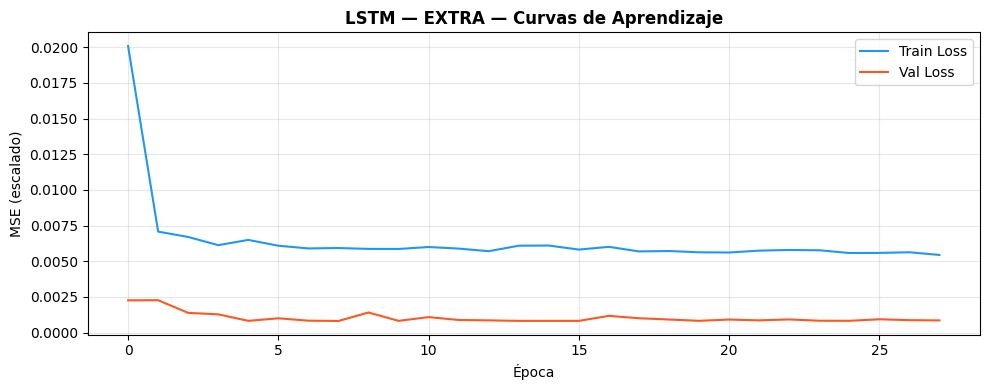

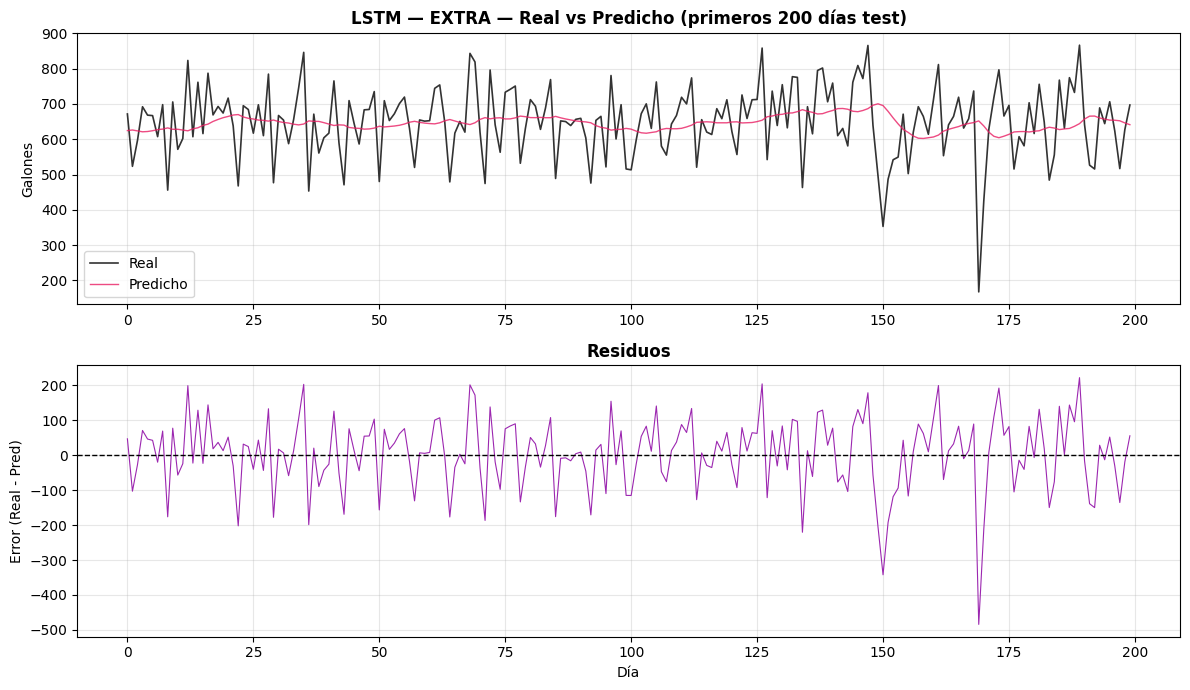


  Modelo: LSTM                 Producto: EXTRA
──────────────────────────────────────────────────────────

  LSTM Univariante — SUPER
Epoch 1/150
29/29 [==============================] - 3s 31ms/step - loss: 0.0176 - val_loss: 0.0088 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 13ms/step - loss: 0.0116 - val_loss: 0.0078 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 13ms/step - loss: 0.0112 - val_loss: 0.0085 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 13ms/step - loss: 0.0111 - val_loss: 0.0079 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 12ms/step - loss: 0.0115 - val_loss: 0.0084 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 12ms/step - loss: 0.0112 - val_loss: 0.0078 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 12ms/step - loss: 0.0111 - val_loss: 0.0082 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 13ms/step - loss: 

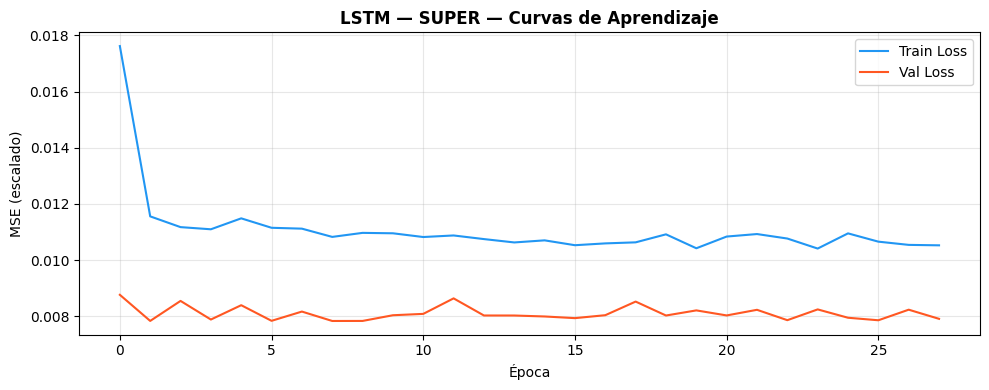

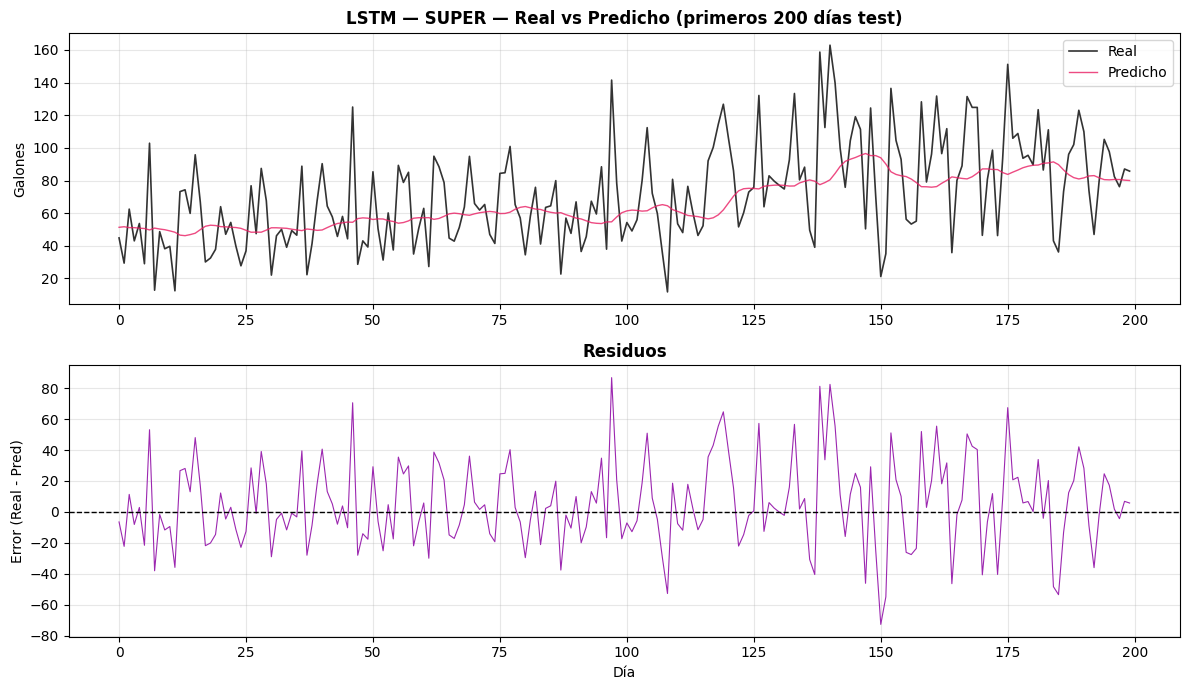


  Modelo: LSTM                 Producto: SUPER
──────────────────────────────────────────────────────────

  LSTM Univariante — DIESEL
Epoch 1/150
29/29 [==============================] - 3s 32ms/step - loss: 0.0593 - val_loss: 0.0186 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 13ms/step - loss: 0.0232 - val_loss: 0.0184 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 12ms/step - loss: 0.0241 - val_loss: 0.0193 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 14ms/step - loss: 0.0232 - val_loss: 0.0183 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 14ms/step - loss: 0.0225 - val_loss: 0.0183 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 14ms/step - loss: 0.0220 - val_loss: 0.0185 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 15ms/step - loss: 0.0226 - val_loss: 0.0196 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 14ms/step - loss:

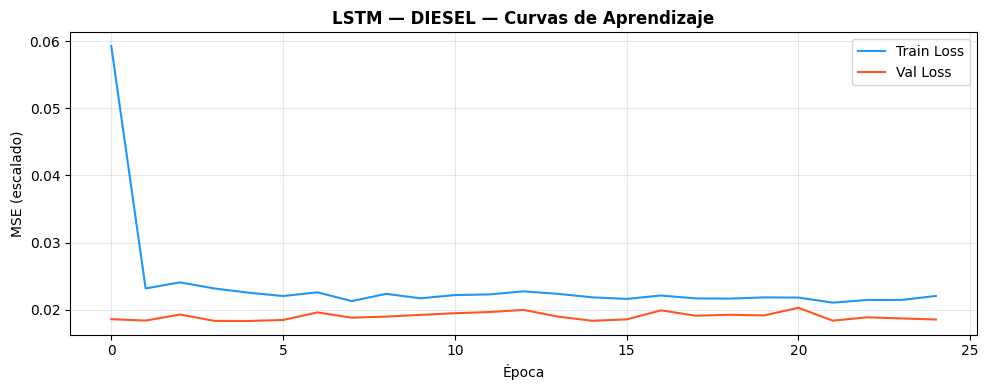

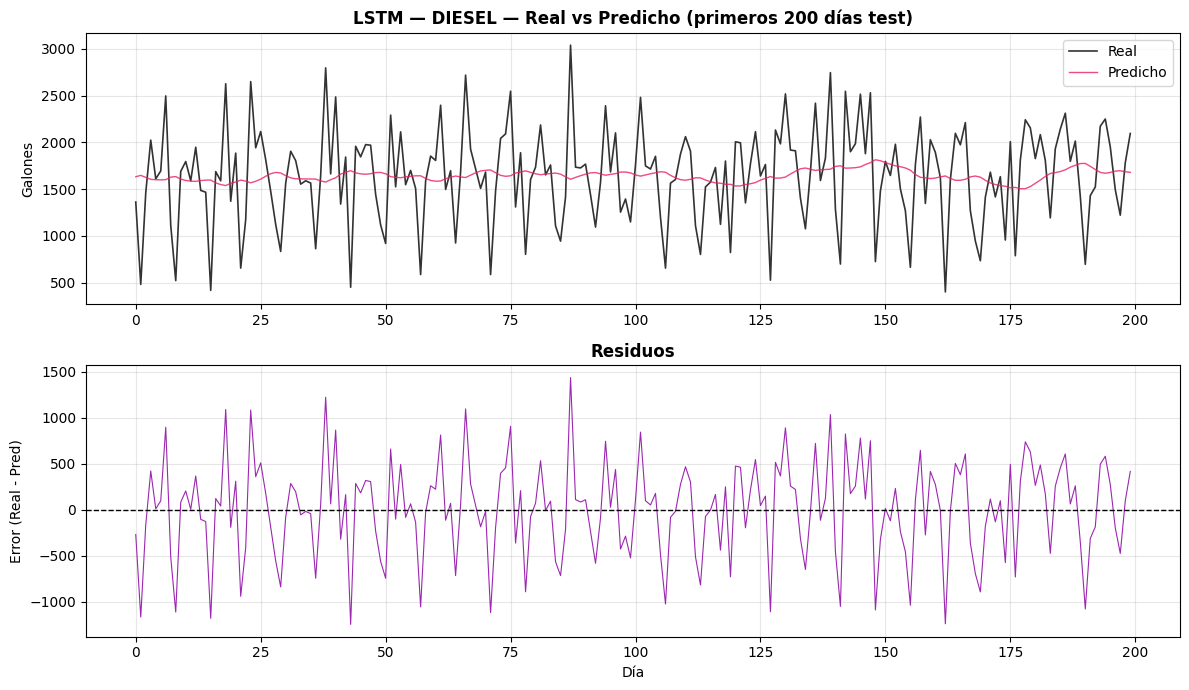


  Modelo: LSTM                 Producto: DIESEL
──────────────────────────────────────────────────────────

✅ LSTM Univariante entrenado para los 3 productos


In [6]:
# ── Entrenar LSTM Univariante para cada producto ──────────────────────────
NOMBRE_ARCH1 = 'LSTM'
historias_lstm = {}

for p in PRODUCTOS:
    print('\n' + '='*60)
    print(f'  LSTM Univariante — {p.upper()}')
    print('='*60)

    X_tr = data[p]['X_train']
    y_tr = data[p]['y_train'].flatten()
    X_v  = data[p]['X_val']
    y_v  = data[p]['y_val'].flatten()
    X_te = data[p]['X_test']
    y_te = data[p]['y_test'].flatten()

    # Validaciones
    assert not np.isnan(X_tr).any(), f'❌ X_train_{p} contiene NaN'
    assert not np.isnan(y_tr).any(), f'❌ y_train_{p} contiene NaN'
    assert X_tr.shape[1] == WINDOW_SIZE, f'❌ WINDOW_SIZE incorrecto: {X_tr.shape}'

    model = build_lstm_univariante(window_size=WINDOW_SIZE, n_features=1,
                                    name=f'lstm_{p}')
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')

    ruta_h5 = os.path.join(PATHS['modelos'], f'modelo_lstm_{p}.h5')
    cb = get_callbacks(ruta_h5)

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb,
        verbose=1
    )
    historias_lstm[p] = hist

    # Cargar el mejor checkpoint
    if os.path.exists(ruta_h5):
        model = keras.models.load_model(ruta_h5)

    # Predicciones desescaladas
    y_pred_sc = model.predict(X_te, verbose=0).flatten()
    y_true_real = desescalar_predicciones(y_te, scalers[p])
    y_pred_real = desescalar_predicciones(y_pred_sc, scalers[p])

    # Graficar
    graficar_historia(
        hist, NOMBRE_ARCH1, p,
        os.path.join(PATHS['graf_eval'], f'hist_lstm_{p}.png')
    )
    graficar_predicciones(
        y_true_real, y_pred_real, NOMBRE_ARCH1, p,
        os.path.join(PATHS['graf_eval'], f'pred_lstm_{p}.png')
    )

    # Métricas
    metricas = calcular_metricas(y_true_real, y_pred_real, NOMBRE_ARCH1, p.upper())
    epocas_ef = len(hist.history['loss'])
    metricas.update({
        'loss_train': round(hist.history['loss'][-1], 6),
        'loss_val':   round(hist.history['val_loss'][-1], 6),
        'n_params':   model.count_params(),
        'epocas_efectivas': epocas_ef,
        'supera_gbr': 1 if metricas['R2'] > GBR_BASELINE[p]['R2'] else 0,
    })
    resultados_todos.append(metricas)

print('\n✅ LSTM Univariante entrenado para los 3 productos')

## 6. Entrenamiento Arch2 — BiLSTM <a id='6'></a>


  BiLSTM — EXTRA
Epoch 1/150
29/29 [==============================] - 5s 50ms/step - loss: 0.0142 - val_loss: 0.0038 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 1s 30ms/step - loss: 0.0064 - val_loss: 0.0011 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 1s 20ms/step - loss: 0.0055 - val_loss: 9.4653e-04 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 1s 20ms/step - loss: 0.0054 - val_loss: 9.2298e-04 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 1s 19ms/step - loss: 0.0057 - val_loss: 9.9115e-04 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 1s 21ms/step - loss: 0.0056 - val_loss: 8.5043e-04 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 1s 20ms/step - loss: 0.0056 - val_loss: 8.2727e-04 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 1s 20ms/step - loss: 0.0056 - val_loss: 8.2094e-04 - lr: 0.0010
Epoch 9/150
29/29 [==============================] - 1

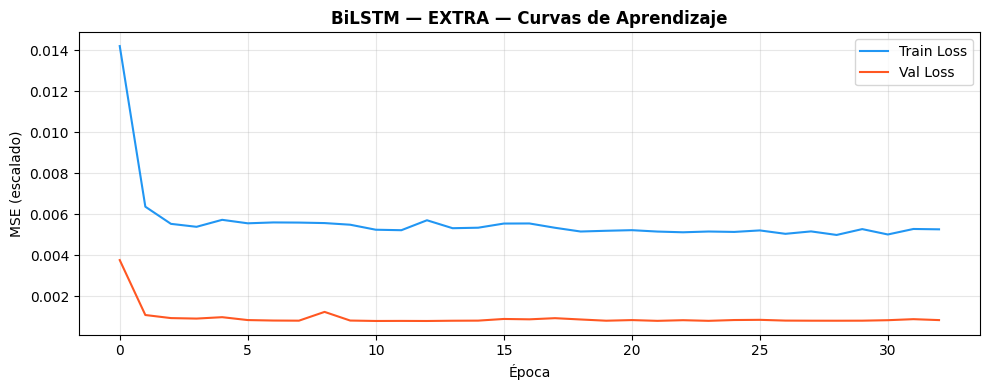

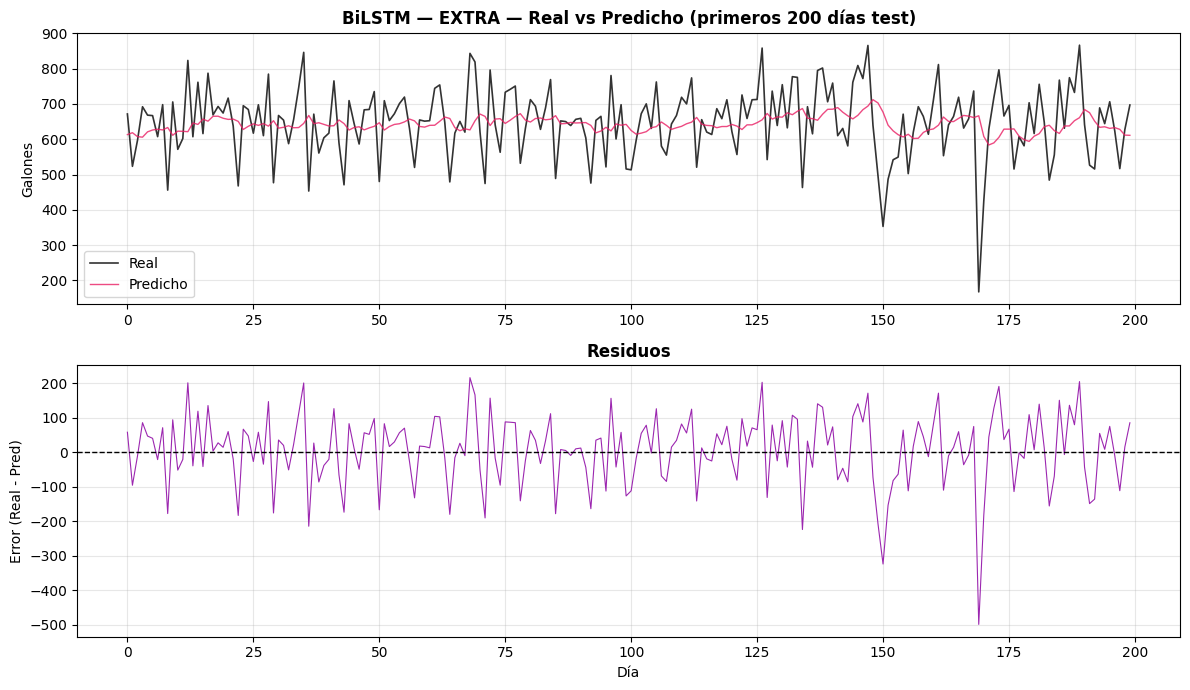


  Modelo: BiLSTM               Producto: EXTRA
──────────────────────────────────────────────────────────

  BiLSTM — SUPER
Epoch 1/150
29/29 [==============================] - 5s 48ms/step - loss: 0.0154 - val_loss: 0.0077 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 14ms/step - loss: 0.0108 - val_loss: 0.0079 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 14ms/step - loss: 0.0111 - val_loss: 0.0087 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 15ms/step - loss: 0.0108 - val_loss: 0.0078 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 15ms/step - loss: 0.0111 - val_loss: 0.0079 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0107 - val_loss: 0.0079 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 1s 17ms/step - loss: 0.0108 - val_loss: 0.0080 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 1s 18ms/step - loss: 0.0105 - v

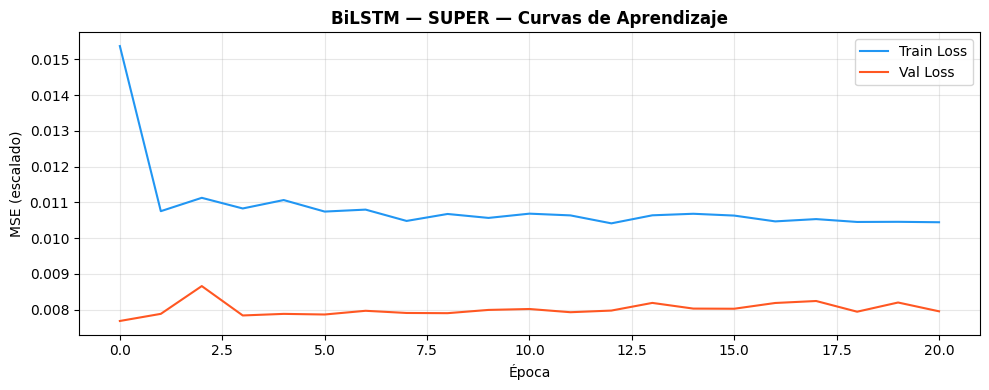

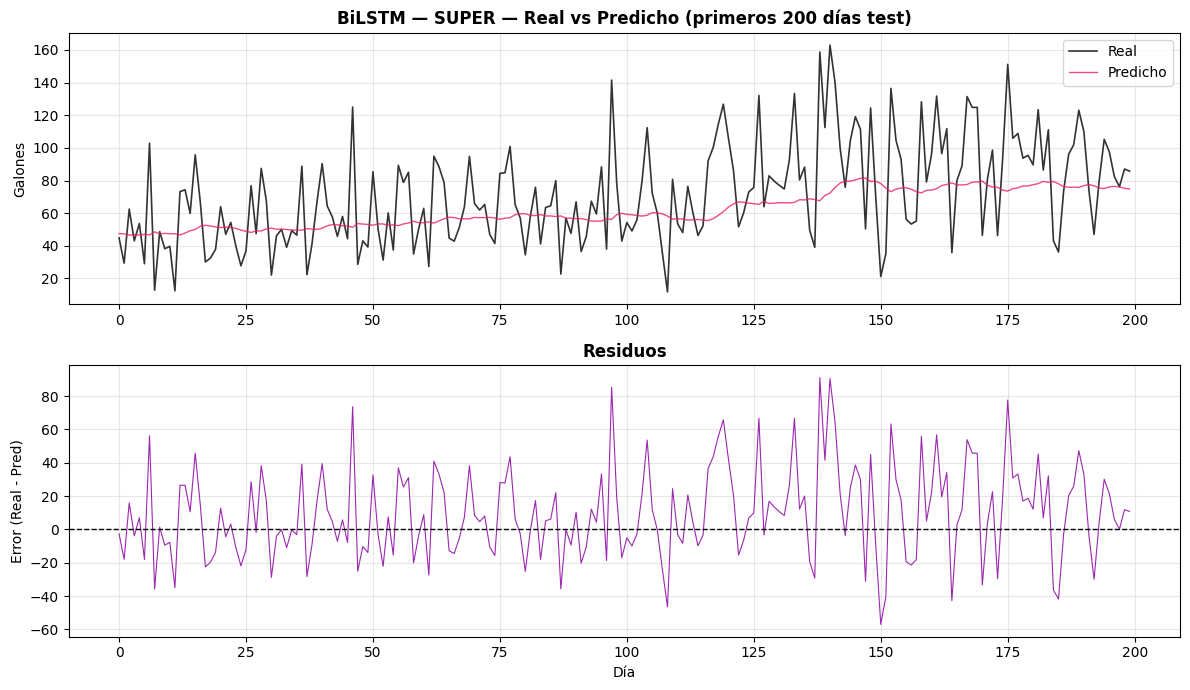


  Modelo: BiLSTM               Producto: SUPER
──────────────────────────────────────────────────────────

  BiLSTM — DIESEL
Epoch 1/150
29/29 [==============================] - 5s 47ms/step - loss: 0.0363 - val_loss: 0.0206 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 16ms/step - loss: 0.0225 - val_loss: 0.0183 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 15ms/step - loss: 0.0213 - val_loss: 0.0194 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 15ms/step - loss: 0.0211 - val_loss: 0.0184 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 1s 18ms/step - loss: 0.0211 - val_loss: 0.0181 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0211 - val_loss: 0.0183 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 17ms/step - loss: 0.0211 - val_loss: 0.0188 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 1s 18ms/step - loss: 0.0210 - 

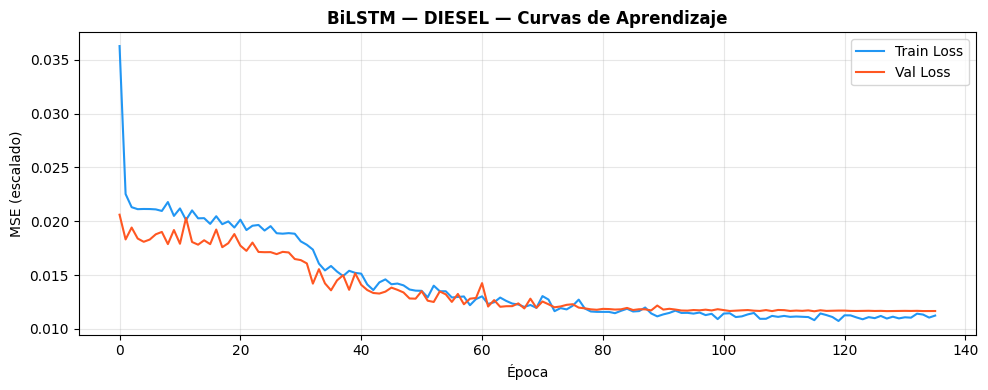

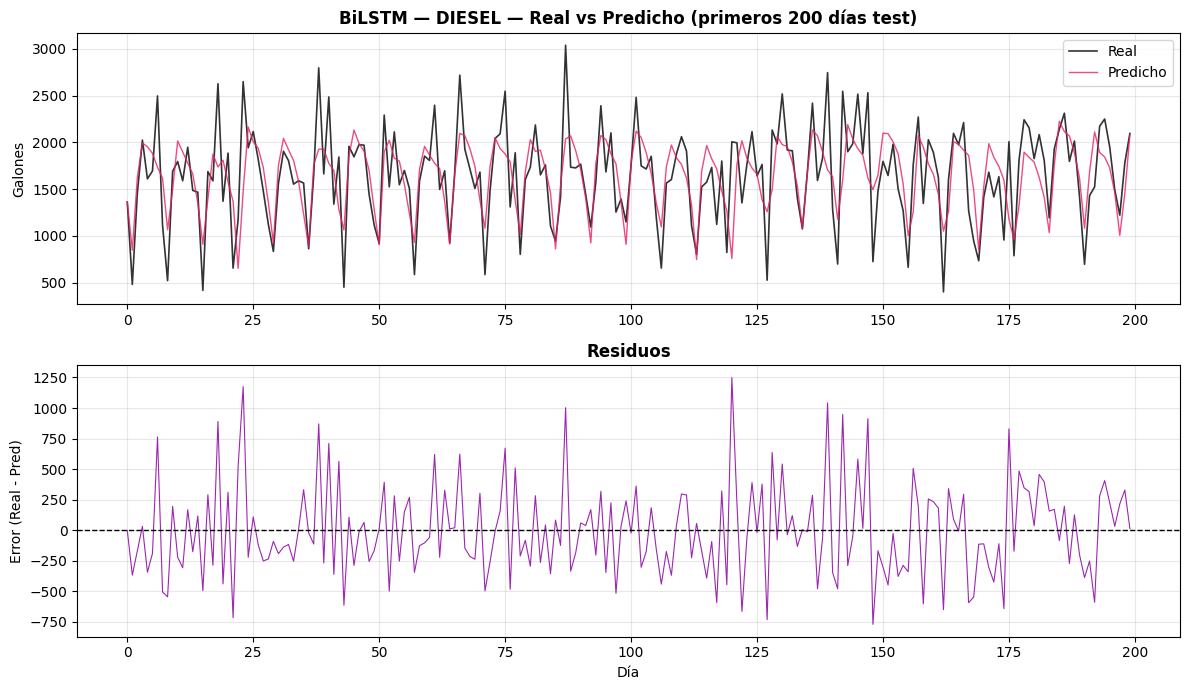


  Modelo: BiLSTM               Producto: DIESEL
──────────────────────────────────────────────────────────

✅ BiLSTM entrenado para los 3 productos


In [7]:
# ── Entrenar BiLSTM para cada producto ───────────────────────────────────
NOMBRE_ARCH2 = 'BiLSTM'
historias_bilstm = {}

for p in PRODUCTOS:
    print('\n' + '='*60)
    print(f'  BiLSTM — {p.upper()}')
    print('='*60)

    X_tr = data[p]['X_train']
    y_tr = data[p]['y_train'].flatten()
    X_v  = data[p]['X_val']
    y_v  = data[p]['y_val'].flatten()
    X_te = data[p]['X_test']
    y_te = data[p]['y_test'].flatten()

    assert not np.isnan(X_tr).any(), f'❌ X_train_{p} contiene NaN'
    assert not np.isnan(y_tr).any(), f'❌ y_train_{p} contiene NaN'

    model = build_bilstm(window_size=WINDOW_SIZE, n_features=1,
                          name=f'bilstm_{p}')
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')

    ruta_h5 = os.path.join(PATHS['modelos'], f'modelo_bilstm_{p}.h5')
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(ruta_h5),
        verbose=1
    )
    historias_bilstm[p] = hist

    if os.path.exists(ruta_h5):
        model = keras.models.load_model(ruta_h5)

    y_pred_sc   = model.predict(X_te, verbose=0).flatten()
    y_true_real = desescalar_predicciones(y_te, scalers[p])
    y_pred_real = desescalar_predicciones(y_pred_sc, scalers[p])

    graficar_historia(hist, NOMBRE_ARCH2, p,
                      os.path.join(PATHS['graf_eval'], f'hist_bilstm_{p}.png'))
    graficar_predicciones(y_true_real, y_pred_real, NOMBRE_ARCH2, p,
                          os.path.join(PATHS['graf_eval'], f'pred_bilstm_{p}.png'))

    metricas = calcular_metricas(y_true_real, y_pred_real, NOMBRE_ARCH2, p.upper())
    metricas.update({
        'loss_train': round(hist.history['loss'][-1], 6),
        'loss_val':   round(hist.history['val_loss'][-1], 6),
        'n_params':   model.count_params(),
        'epocas_efectivas': len(hist.history['loss']),
        'supera_gbr': 1 if metricas['R2'] > GBR_BASELINE[p]['R2'] else 0,
    })
    resultados_todos.append(metricas)

print('\n✅ BiLSTM entrenado para los 3 productos')

## 7. Entrenamiento Arch3 — CNN-LSTM <a id='7'></a>


  CNN-LSTM — EXTRA
Epoch 1/150
29/29 [==============================] - 2s 18ms/step - loss: 0.0148 - val_loss: 0.0011 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0061 - val_loss: 0.0016 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0059 - val_loss: 0.0012 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 8ms/step - loss: 0.0056 - val_loss: 0.0011 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 10ms/step - loss: 0.0060 - val_loss: 8.3573e-04 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 8ms/step - loss: 0.0055 - val_loss: 0.0010 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0052 - val_loss: 8.6348e-04 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0055 - val_loss: 8.3936e-04 - lr: 0.0010
Epoch 9/150
29/29 [==============================] - 0s 7ms/step - los

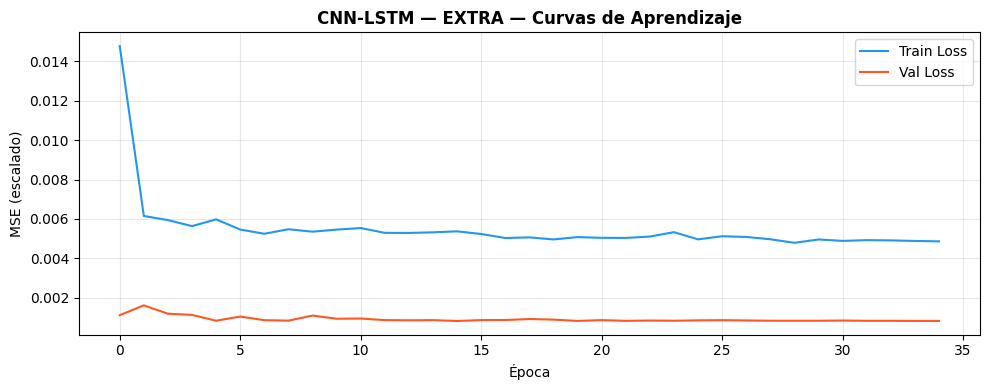

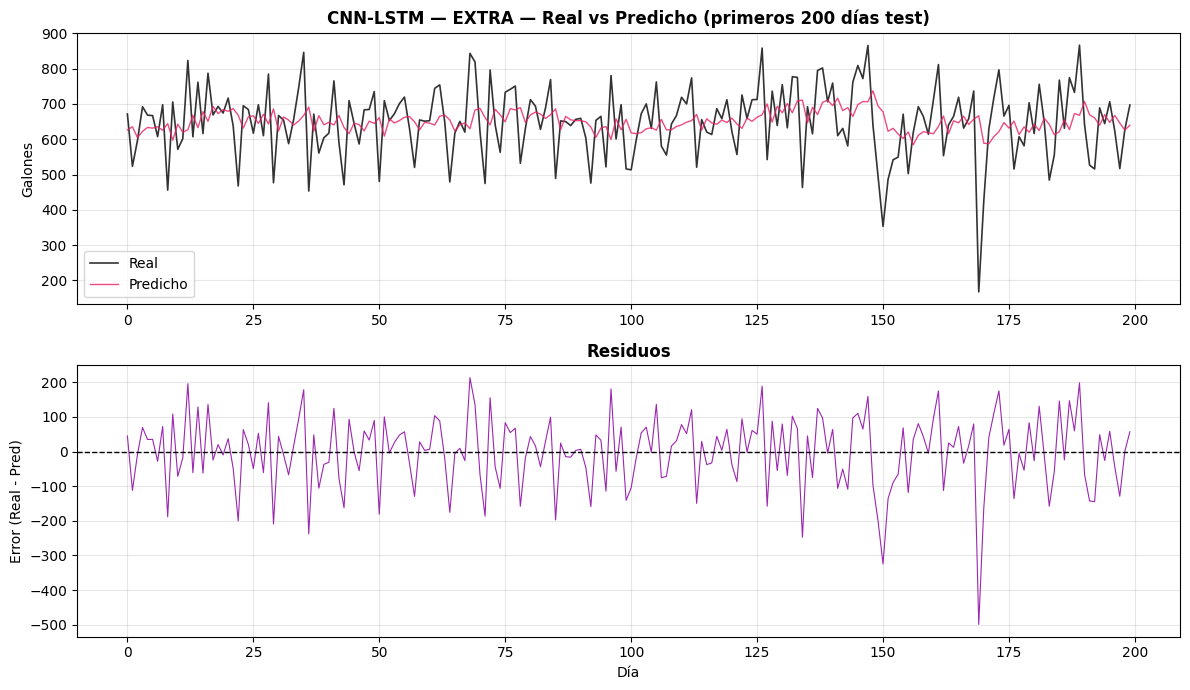


  Modelo: CNN-LSTM             Producto: EXTRA
──────────────────────────────────────────────────────────

  CNN-LSTM — SUPER
Epoch 1/150
29/29 [==============================] - 2s 17ms/step - loss: 0.0186 - val_loss: 0.0101 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0113 - val_loss: 0.0082 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0110 - val_loss: 0.0079 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0110 - val_loss: 0.0084 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0110 - val_loss: 0.0082 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0109 - val_loss: 0.0079 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0109 - val_loss: 0.0083 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0106 - val_lo

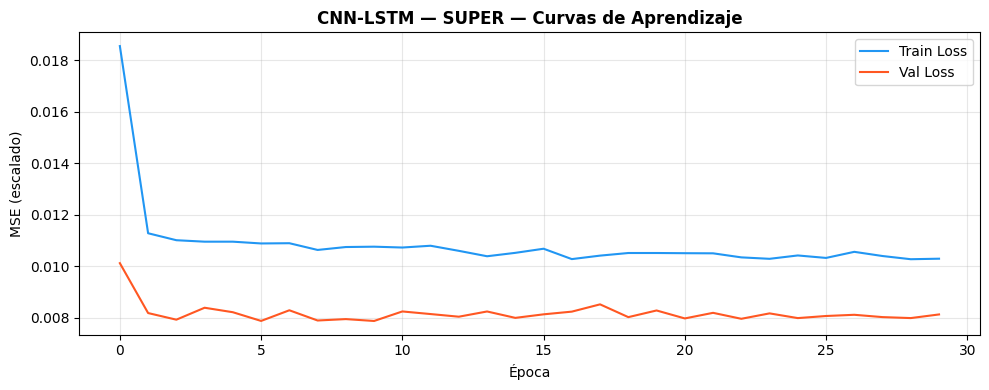

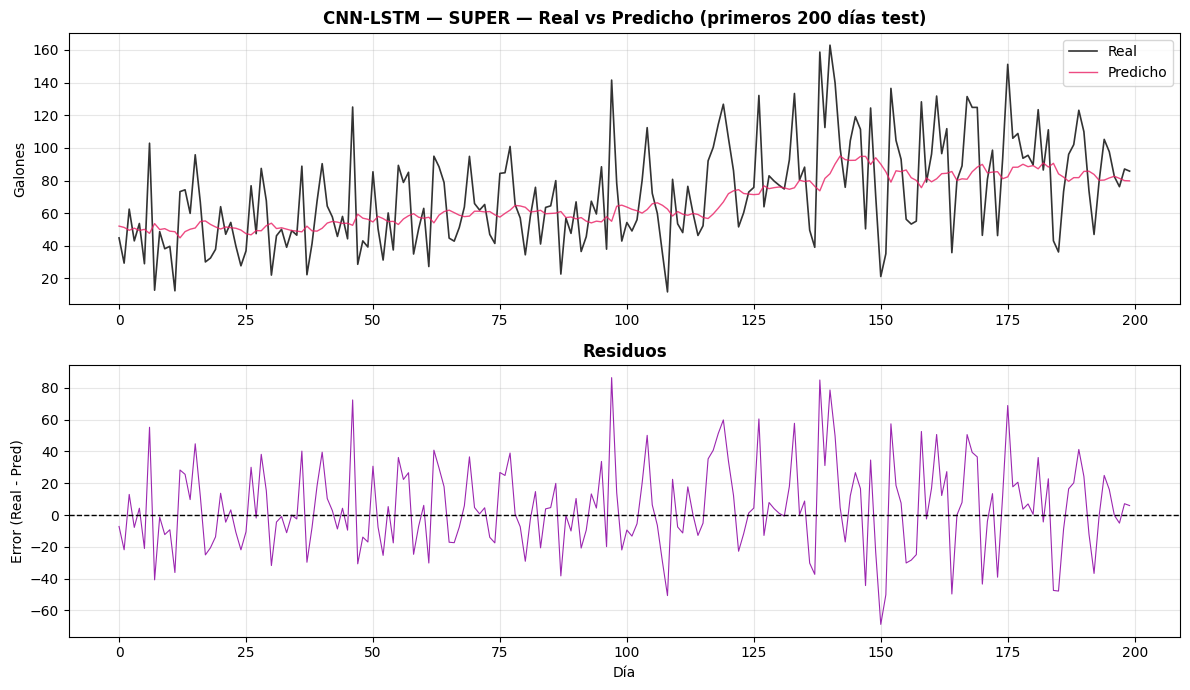


  Modelo: CNN-LSTM             Producto: SUPER
──────────────────────────────────────────────────────────

  CNN-LSTM — DIESEL
Epoch 1/150
29/29 [==============================] - 2s 17ms/step - loss: 0.0485 - val_loss: 0.0188 - lr: 0.0010
Epoch 2/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0216 - val_loss: 0.0185 - lr: 0.0010
Epoch 3/150
29/29 [==============================] - 0s 5ms/step - loss: 0.0215 - val_loss: 0.0196 - lr: 0.0010
Epoch 4/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0217 - val_loss: 0.0183 - lr: 0.0010
Epoch 5/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0216 - val_loss: 0.0179 - lr: 0.0010
Epoch 6/150
29/29 [==============================] - 0s 7ms/step - loss: 0.0204 - val_loss: 0.0176 - lr: 0.0010
Epoch 7/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0198 - val_loss: 0.0192 - lr: 0.0010
Epoch 8/150
29/29 [==============================] - 0s 6ms/step - loss: 0.0196 - val_l

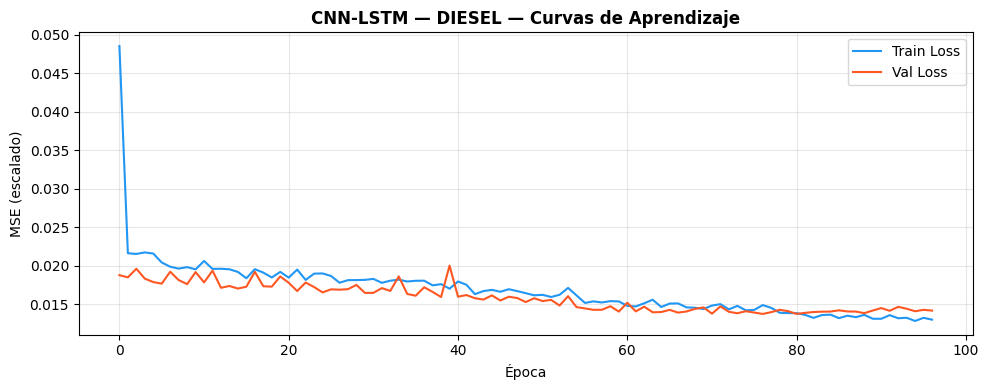

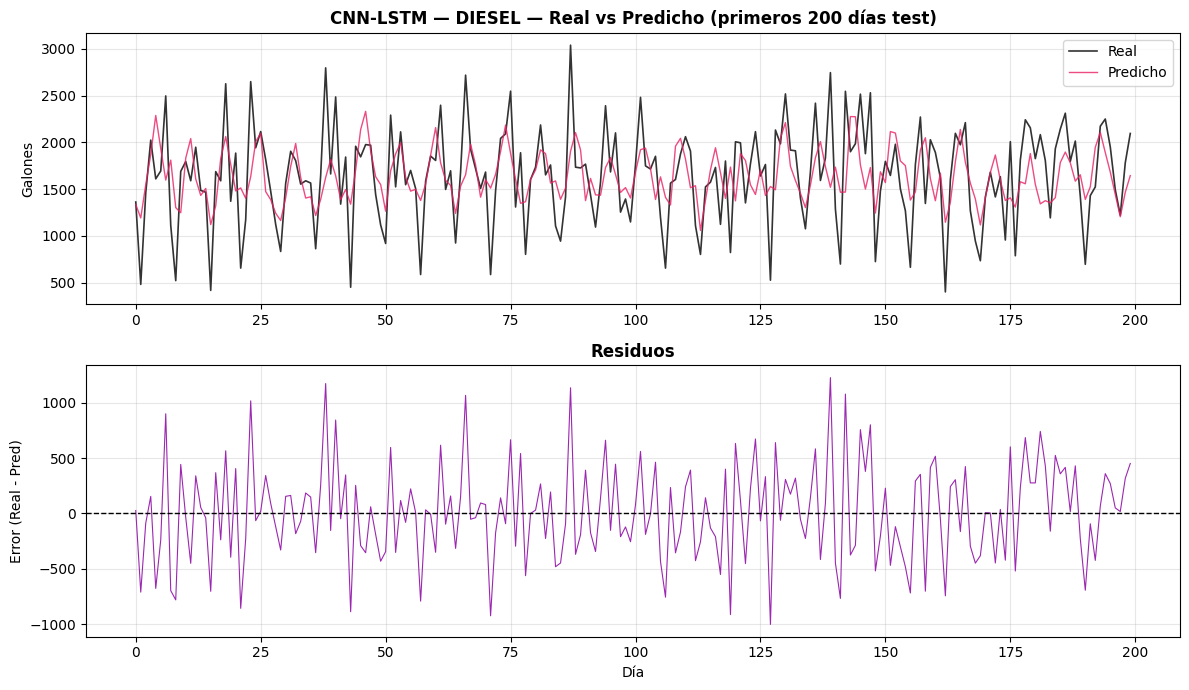


  Modelo: CNN-LSTM             Producto: DIESEL
──────────────────────────────────────────────────────────

✅ CNN-LSTM entrenado para los 3 productos


In [8]:
# ── Entrenar CNN-LSTM para cada producto ──────────────────────────────────
NOMBRE_ARCH3 = 'CNN-LSTM'
historias_cnnlstm = {}

for p in PRODUCTOS:
    print('\n' + '='*60)
    print(f'  CNN-LSTM — {p.upper()}')
    print('='*60)

    X_tr = data[p]['X_train']
    y_tr = data[p]['y_train'].flatten()
    X_v  = data[p]['X_val']
    y_v  = data[p]['y_val'].flatten()
    X_te = data[p]['X_test']
    y_te = data[p]['y_test'].flatten()

    assert not np.isnan(X_tr).any(), f'❌ X_train_{p} contiene NaN'
    assert not np.isnan(y_tr).any(), f'❌ y_train_{p} contiene NaN'

    model = build_cnn_lstm(window_size=WINDOW_SIZE, n_features=1,
                            name=f'cnnlstm_{p}')
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')

    ruta_h5 = os.path.join(PATHS['modelos'], f'modelo_cnn_lstm_{p}.h5')
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(ruta_h5),
        verbose=1
    )
    historias_cnnlstm[p] = hist

    if os.path.exists(ruta_h5):
        model = keras.models.load_model(ruta_h5)

    y_pred_sc   = model.predict(X_te, verbose=0).flatten()
    y_true_real = desescalar_predicciones(y_te, scalers[p])
    y_pred_real = desescalar_predicciones(y_pred_sc, scalers[p])

    graficar_historia(hist, NOMBRE_ARCH3, p,
                      os.path.join(PATHS['graf_eval'], f'hist_cnnlstm_{p}.png'))
    graficar_predicciones(y_true_real, y_pred_real, NOMBRE_ARCH3, p,
                          os.path.join(PATHS['graf_eval'], f'pred_cnnlstm_{p}.png'))

    metricas = calcular_metricas(y_true_real, y_pred_real, NOMBRE_ARCH3, p.upper())
    metricas.update({
        'loss_train': round(hist.history['loss'][-1], 6),
        'loss_val':   round(hist.history['val_loss'][-1], 6),
        'n_params':   model.count_params(),
        'epocas_efectivas': len(hist.history['loss']),
        'supera_gbr': 1 if metricas['R2'] > GBR_BASELINE[p]['R2'] else 0,
    })
    resultados_todos.append(metricas)

print('\n✅ CNN-LSTM entrenado para los 3 productos')

## 8. Entrenamiento Arch4 — LSTM Multivariante <a id='8'></a>

Shapes — X_train: (924, 30, 3), y_train: (924, 3)
Model: "LSTM-Multi"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 30, 3)]           0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           67584     
                                                                 
 dropout_22 (Dropout)        (None, 30, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_23 (Dropout)        (None, 64)                0         
                                                                 
 output (Dense)              (None, 3)                 195       
                                                                 
Total 

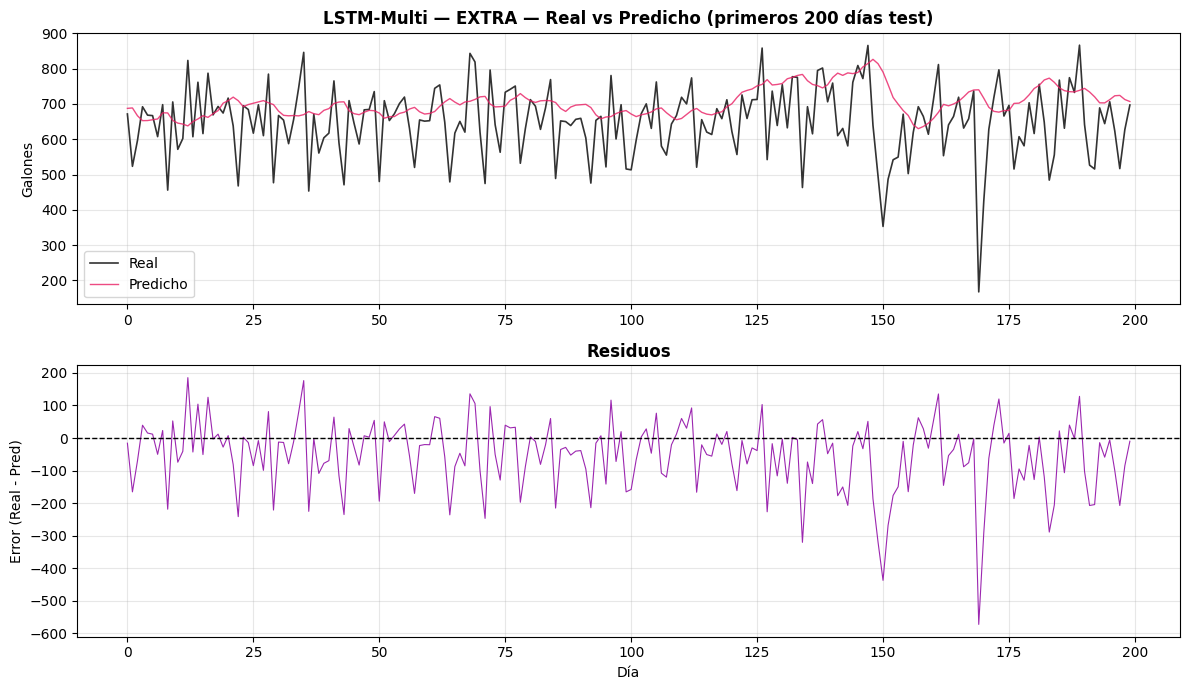


  Modelo: LSTM-Multi           Producto: EXTRA
──────────────────────────────────────────────────────────


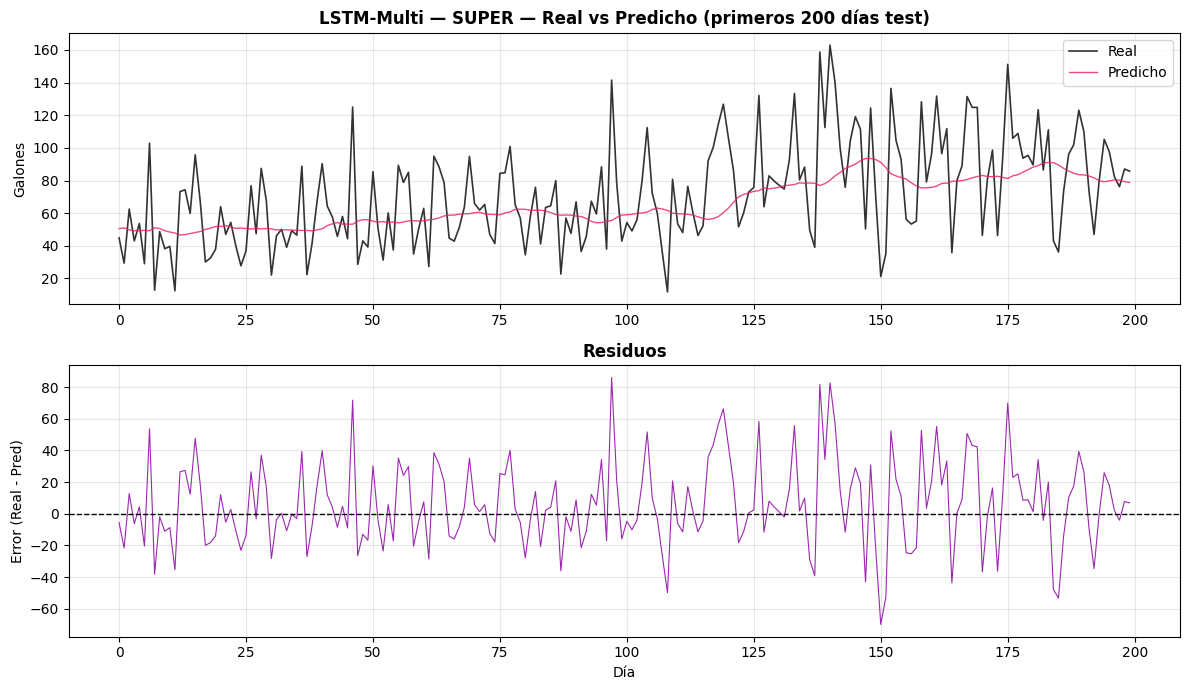


  Modelo: LSTM-Multi           Producto: SUPER
──────────────────────────────────────────────────────────


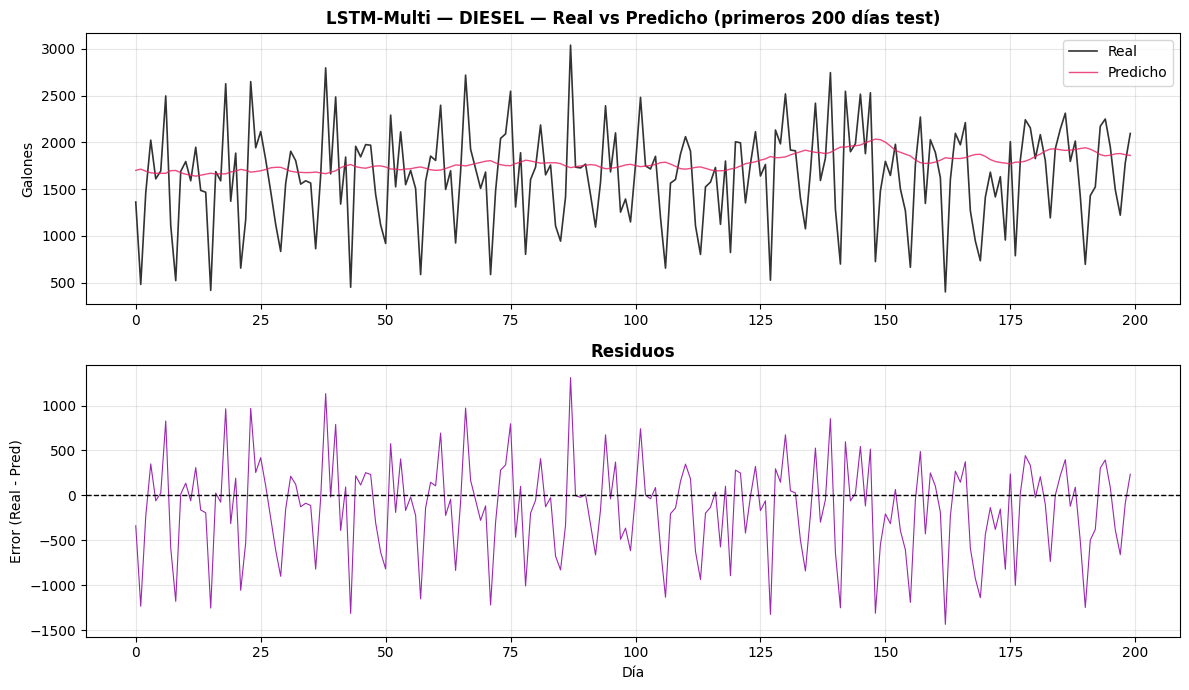


  Modelo: LSTM-Multi           Producto: DIESEL
──────────────────────────────────────────────────────────


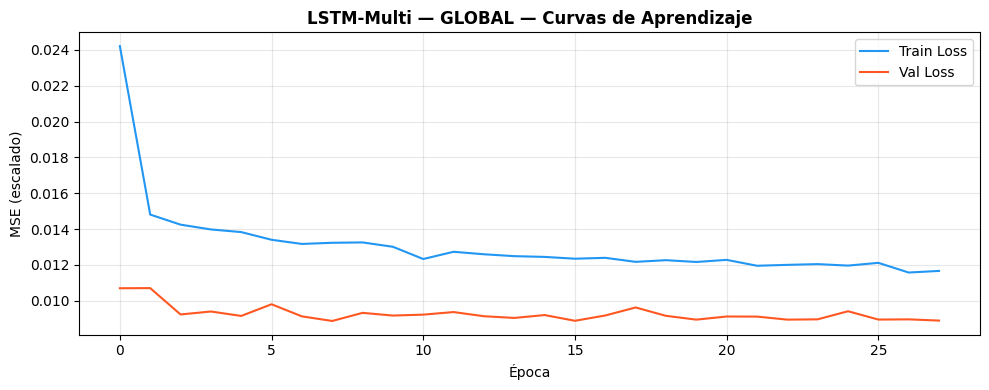


✅ LSTM Multivariante entrenado


In [9]:
# ── Entrenar LSTM Multivariante (predice los 3 productos a la vez) ────────
NOMBRE_ARCH4 = 'LSTM-Multi'

X_tr_m = data['multi']['X_train']
y_tr_m = data['multi']['y_train']
X_v_m  = data['multi']['X_val']
y_v_m  = data['multi']['y_val']
X_te_m = data['multi']['X_test']
y_te_m = data['multi']['y_test']

print(f'Shapes — X_train: {X_tr_m.shape}, y_train: {y_tr_m.shape}')

assert not np.isnan(X_tr_m).any(), '❌ X_train_multi contiene NaN'
assert not np.isnan(y_tr_m).any(), '❌ y_train_multi contiene NaN'

n_features_m = X_tr_m.shape[2]  # = 3
n_outputs_m  = y_tr_m.shape[1]  # = 3

model_multi = build_lstm_multivariante(
    window_size=WINDOW_SIZE, n_features=n_features_m, n_outputs=n_outputs_m
)
model_multi.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')
model_multi.summary()

ruta_h5_multi = os.path.join(PATHS['modelos'], 'modelo_lstm_multi_global.h5')
hist_multi = model_multi.fit(
    X_tr_m, y_tr_m,
    validation_data=(X_v_m, y_v_m),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(ruta_h5_multi),
    verbose=1
)

if os.path.exists(ruta_h5_multi):
    model_multi = keras.models.load_model(ruta_h5_multi)

# Predicciones y desescalado con el scaler multivariante
y_pred_m_sc   = model_multi.predict(X_te_m, verbose=0)  # (n, 3)
y_true_m_real = scalers['multi'].inverse_transform(y_te_m)  # (n, 3)
y_pred_m_real = scalers['multi'].inverse_transform(y_pred_m_sc)  # (n, 3)

for i, p in enumerate(PRODUCTOS):
    graficar_predicciones(
        y_true_m_real[:, i], y_pred_m_real[:, i], NOMBRE_ARCH4, p,
        os.path.join(PATHS['graf_eval'], f'pred_lstmmulti_{p}.png')
    )
    metricas = calcular_metricas(
        y_true_m_real[:, i], y_pred_m_real[:, i], NOMBRE_ARCH4, p.upper()
    )
    metricas.update({
        'loss_train': round(hist_multi.history['loss'][-1], 6),
        'loss_val':   round(hist_multi.history['val_loss'][-1], 6),
        'n_params':   model_multi.count_params(),
        'epocas_efectivas': len(hist_multi.history['loss']),
        'supera_gbr': 1 if metricas['R2'] > GBR_BASELINE[p]['R2'] else 0,
    })
    resultados_todos.append(metricas)

graficar_historia(
    hist_multi, NOMBRE_ARCH4, 'global',
    os.path.join(PATHS['graf_eval'], 'hist_lstmmulti.png')
)
print('\n✅ LSTM Multivariante entrenado')

## 9. Comparación con baseline GBR <a id='9'></a>

In [10]:
# ── Añadir filas GBR-Baseline ────────────────────────────────────────────
for p in PRODUCTOS:
    gbr = GBR_BASELINE[p].copy()
    gbr.update({
        'modelo': 'GBR-Baseline', 'producto': p.upper(),
        'loss_train': None, 'loss_val': None,
        'n_params': None, 'epocas_efectivas': None, 'supera_gbr': 0,
    })
    resultados_todos.append(gbr)

# ── Crear DataFrame de resultados completo ───────────────────────────────
df_bench = pd.DataFrame(resultados_todos)

print('\n=== TABLA COMPARATIVA COMPLETA ===')
display(df_bench.sort_values(['producto', 'R2'], ascending=[True, False]))

# Guardar
df_bench.to_csv(os.path.join(PATHS['data'], 'benchmark_resultados.csv'), index=False)
print('\n✅ benchmark_resultados.csv guardado')


=== TABLA COMPARATIVA COMPLETA ===


,modelo,producto,MAE,RMSE,sMAPE,MAPE,R2,DA,loss_train,loss_val,n_params,epocas_efectivas,supera_gbr
5,BiLSTM,DIESEL,311.0027,400.3334,21.1968,5940.4884,0.4339,68.29,0.011232,0.011654,75073.0,136.0,1
8,CNN-LSTM,DIESEL,362.9275,466.5379,24.5460,6914.8170,0.2312,61.46,0.012971,0.014148,23307.0,97.0,1
14,GBR-Baseline,DIESEL,383.1200,499.3200,25.6000,25.6000,0.1790,50.00,NaN,NaN,NaN,NaN,0
2,LSTM,DIESEL,413.6395,544.0415,27.5476,6743.0283,-0.0454,29.76,0.022032,0.018525,29345.0,25.0,0
11,LSTM-Multi,DIESEL,413.9968,561.3164,27.2481,7521.3791,-0.1128,26.83,0.011670,0.008901,117187.0,28.0,0
12,GBR-Baseline,EXTRA,76.1000,103.5100,12.3200,12.3200,-0.0290,50.00,NaN,NaN,NaN,NaN,0
0,LSTM,EXTRA,81.1110,109.5999,13.1269,15.9459,-0.0618,35.61,0.005448,0.000859,29345.0,28.0,0
3,BiLSTM,EXTRA,82.1016,109.6947,13.2811,16.0661,-0.0636,32.20,0.005275,0.000849,75073.0,33.0,0
6,CNN-LSTM,EXTRA,82.8643,109.9080,13.3913,16.2942,-0.0678,29.27,0.004862,0.000825,23307.0,35.0,0
9,LSTM-Multi,EXTRA,87.7543,126.7088,13.9269,18.4912,-0.4191,42.93,0.011670,0.008901,117187.0,28.0,0



✅ benchmark_resultados.csv guardado


## 10. Selección del modelo ganador <a id='10'></a>

In [11]:
# ── Criterio de selección del ganador ────────────────────────────────────
# 1. Mayor R² promedio entre los 3 productos
# 2. En empate: menor sMAPE promedio
# 3. En empate final: mayor DA promedio

df_nn = df_bench[df_bench['modelo'] != 'GBR-Baseline'].copy()

ranking = (
    df_nn.groupby('modelo')
    .agg(R2_mean=('R2', 'mean'), sMAPE_mean=('sMAPE', 'mean'), DA_mean=('DA', 'mean'))
    .sort_values(['R2_mean', 'sMAPE_mean', 'DA_mean'],
                 ascending=[False, True, False])
    .reset_index()
)

print('\n=== RANKING DE ARQUITECTURAS ===')
display(ranking)

MODELO_GANADOR = ranking.iloc[0]['modelo']
print(f'\n🏆 MODELO GANADOR: {MODELO_GANADOR}')
print(f'   R² promedio:    {ranking.iloc[0]["R2_mean"]:.4f}')
print(f'   sMAPE promedio: {ranking.iloc[0]["sMAPE_mean"]:.2f}%')
print(f'   DA promedio:    {ranking.iloc[0]["DA_mean"]:.1f}%')

# Verificar umbral para superar GBR
gbr_r2_promedio = np.mean([GBR_BASELINE[p]['R2'] for p in PRODUCTOS])
gbr_smape_promedio = np.mean([GBR_BASELINE[p]['sMAPE'] for p in PRODUCTOS])
supera_gbr = (
    ranking.iloc[0]['R2_mean'] > gbr_r2_promedio and
    ranking.iloc[0]['sMAPE_mean'] < gbr_smape_promedio
)
print(f'\n   ¿Supera GBR-Baseline? → {"✅ SÍ" if supera_gbr else "⚠️  NO (revisar regularización)"}')

# Guardar nombre del ganador
with open(os.path.join(PATHS['data'], 'modelo_ganador.txt'), 'w') as f:
    f.write(MODELO_GANADOR)
print(f'\n✅ modelo_ganador.txt guardado: {MODELO_GANADOR}')


=== RANKING DE ARQUITECTURAS ===


,modelo,R2_mean,sMAPE_mean,DA_mean
0,BiLSTM,0.160600,22.689133,42.926667
1,CNN-LSTM,0.114833,23.338233,39.836667
2,LSTM,0.019667,24.373733,33.010000
3,LSTM-Multi,-0.118200,24.430767,37.073333



🏆 MODELO GANADOR: BiLSTM
   R² promedio:    0.1606
   sMAPE promedio: 22.69%
   DA promedio:    42.9%

   ¿Supera GBR-Baseline? → ✅ SÍ

✅ modelo_ganador.txt guardado: BiLSTM


## 11. Guardado de resultados y modelos finales <a id='11'></a>

In [12]:
# ── Errores detallados del modelo ganador ───────────────────────────────────
df_ganador = df_bench[df_bench['modelo'] == MODELO_GANADOR].copy()

# Calcular sesgo (bias) para el ganador — necesitamos recargar predicciones
# Usamos los valores que ya tenemos en df_bench
filas_errores = []
for p in PRODUCTOS:
    row = df_ganador[df_ganador['producto'] == p.upper()].iloc[0]
    filas_errores.append({
        'producto':       p.upper(),
        'MAE':            row['MAE'],
        'sesgo_promedio': None,    # se calcula solo si recargamos las predicciones
        'real_promedio':  None,
        'pred_promedio':  None,
    })

# Para calcular sesgo, recargamos el modelo ganador y evaluamos
MAPA_MODELOS = {
    'LSTM':       'modelo_lstm_{p}.h5',
    'BiLSTM':     'modelo_bilstm_{p}.h5',
    'CNN-LSTM':   'modelo_cnn_lstm_{p}.h5',
    'LSTM-Multi': 'modelo_lstm_multi_global.h5',
}
patron = MAPA_MODELOS.get(MODELO_GANADOR, 'modelo_lstm_{p}.h5')

filas_errores_v2 = []
for i, p in enumerate(PRODUCTOS):
    if MODELO_GANADOR == 'LSTM-Multi':
        m = keras.models.load_model(os.path.join(PATHS['modelos'], 'modelo_lstm_multi_global.h5'))
        y_pred_sc = m.predict(data['multi']['X_test'], verbose=0)
        y_true_r  = scalers['multi'].inverse_transform(data['multi']['y_test'])[:, i]
        y_pred_r  = scalers['multi'].inverse_transform(y_pred_sc)[:, i]
    else:
        nombre_h5 = patron.replace('{p}', p)
        m = keras.models.load_model(os.path.join(PATHS['modelos'], nombre_h5))
        y_pred_sc = m.predict(data[p]['X_test'], verbose=0).flatten()
        y_true_r  = desescalar_predicciones(data[p]['y_test'], scalers[p])
        y_pred_r  = desescalar_predicciones(y_pred_sc, scalers[p])

    sesgo = float(np.mean(y_pred_r - y_true_r))
    filas_errores_v2.append({
        'producto':       p.upper(),
        'MAE':            round(float(mean_absolute_error(y_true_r, y_pred_r)), 4),
        'sesgo_promedio': round(sesgo, 4),
        'real_promedio':  round(float(np.mean(y_true_r)), 4),
        'pred_promedio':  round(float(np.mean(y_pred_r)), 4),
    })

df_errores = pd.DataFrame(filas_errores_v2)
df_errores.to_csv(os.path.join(PATHS['data'], 'errores_por_producto.csv'), index=False)
print('✅ errores_por_producto.csv guardado')
display(df_errores)

✅ errores_por_producto.csv guardado


,producto,MAE,sesgo_promedio,real_promedio,pred_promedio
0,EXTRA,82.1016,-5.4317,648.0345,642.6028
1,SUPER,22.9304,-9.7027,72.1594,62.4567
2,DIESEL,311.0027,11.1455,1637.5612,1648.7068


In [13]:
# ── metricas_finales.csv (para incluir en el documento de tesis) ─────────
cols_finales = ['modelo', 'producto', 'MAE', 'RMSE', 'sMAPE', 'R2']

df_mf_ganador = df_bench[
    df_bench['modelo'] == MODELO_GANADOR
][cols_finales].copy()

df_mf_gbr = df_bench[
    df_bench['modelo'] == 'GBR-Baseline'
][cols_finales].copy()

df_metricas_finales = pd.concat([df_mf_gbr, df_mf_ganador], ignore_index=True)
df_metricas_finales.to_csv(os.path.join(PATHS['data'], 'metricas_finales.csv'), index=False)
print('✅ metricas_finales.csv guardado')
display(df_metricas_finales)

✅ metricas_finales.csv guardado


,modelo,producto,MAE,RMSE,sMAPE,R2
0,GBR-Baseline,EXTRA,76.1000,103.5100,12.3200,-0.0290
1,GBR-Baseline,SUPER,19.0100,24.7900,31.9000,0.3220
2,GBR-Baseline,DIESEL,383.1200,499.3200,25.6000,0.1790
3,BiLSTM,EXTRA,82.1016,109.6947,13.2811,-0.0636
4,BiLSTM,SUPER,22.9304,29.6070,33.5895,0.1115
5,BiLSTM,DIESEL,311.0027,400.3334,21.1968,0.4339


In [14]:
# ── Guardar modelo_final_nn.h5 (copia del ganador) ────────────────────────
import shutil

if MODELO_GANADOR == 'LSTM-Multi':
    fuente = os.path.join(PATHS['modelos'], 'modelo_lstm_multi_global.h5')
else:
    # Para modelos univariantes, elegir el de mejor R2
    mejor_prod = (
        df_ganador.sort_values('R2', ascending=False)
        .iloc[0]['producto'].lower()
    )
    patron_uni = MAPA_MODELOS[MODELO_GANADOR].replace('{p}', mejor_prod)
    fuente = os.path.join(PATHS['modelos'], patron_uni)

destino = os.path.join(PATHS['modelos'], 'modelo_final_nn.h5')
if os.path.exists(fuente):
    shutil.copy2(fuente, destino)
    print(f'✅ modelo_final_nn.h5 guardado (copia de {os.path.basename(fuente)})')
else:
    print(f'⚠️  Fuente no encontrada: {fuente}')

✅ modelo_final_nn.h5 guardado (copia de modelo_bilstm_diesel.h5)


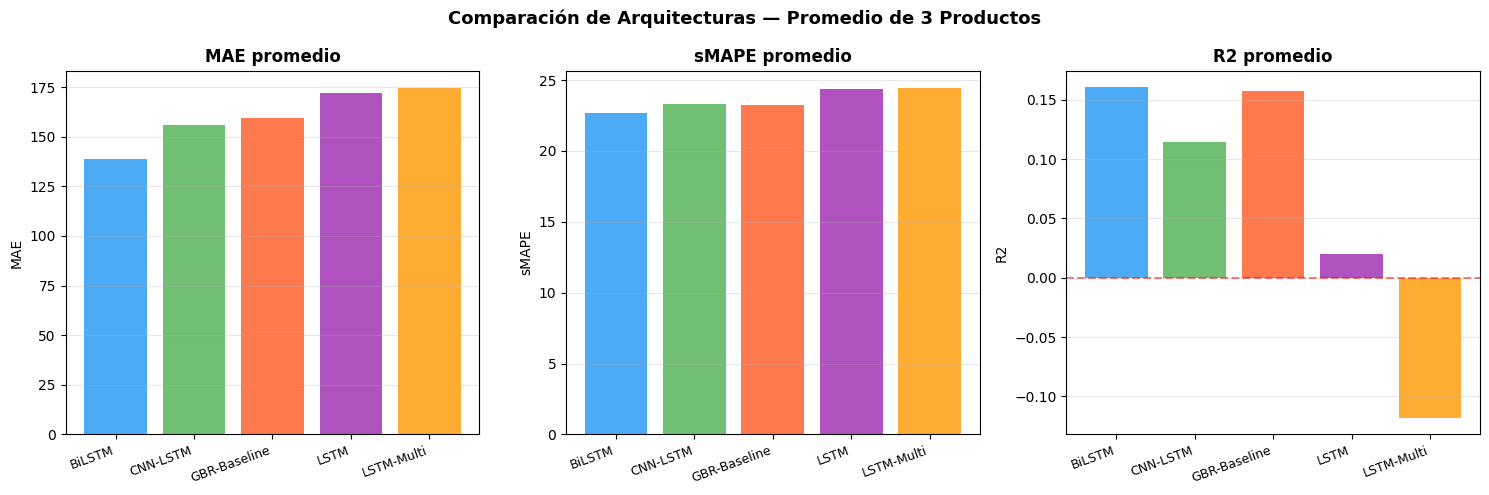

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\evaluacion\comparacion_arquitecturas.png


In [15]:
# ── Gráfico comparativo de métricas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_graf = ['MAE', 'sMAPE', 'R2']

modelos_nn = df_bench[df_bench['modelo'] != 'GBR-Baseline']['modelo'].unique()
colores_mod = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for ax, metrica in zip(axes, metricas_graf):
    for i, prod in enumerate(PRODUCTOS):
        df_prod = df_bench[df_bench['producto'] == prod.upper()]
        df_prod_nn = df_prod[df_prod['modelo'] != 'GBR-Baseline']
        df_gbr     = df_prod[df_prod['modelo'] == 'GBR-Baseline']
        x = np.arange(len(modelos_nn))
    
    df_pivot = (
        df_bench[df_bench['producto'].isin([p.upper() for p in PRODUCTOS])]
        .groupby('modelo')[metrica].mean()
    )
    bars = ax.bar(range(len(df_pivot)), df_pivot.values,
                  color=[colores_mod[j] for j in range(len(df_pivot))],
                  alpha=0.8)
    ax.set_xticks(range(len(df_pivot)))
    ax.set_xticklabels(df_pivot.index, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{metrica} promedio', fontweight='bold')
    ax.set_ylabel(metrica)
    ax.grid(True, alpha=0.3, axis='y')
    if metrica == 'R2':
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Comparación de Arquitecturas — Promedio de 3 Productos', fontsize=13, fontweight='bold')
plt.tight_layout()
ruta_comp = os.path.join(PATHS['graf_eval'], 'comparacion_arquitecturas.png')
plt.savefig(ruta_comp, bbox_inches='tight', dpi=120)
plt.show()
print(f'✅ Guardado: {ruta_comp}')

## 12. Verificación final <a id='12'></a>

In [16]:
print('=' * 60)
print('  VERIFICACIÓN FINAL — NOTEBOOK 04')
print('=' * 60)

archivos_data = [
    'benchmark_resultados.csv',
    'modelo_ganador.txt',
    'errores_por_producto.csv',
    'metricas_finales.csv',
]
archivos_modelos = [
    'modelo_lstm_extra.h5', 'modelo_lstm_super.h5', 'modelo_lstm_diesel.h5',
    'modelo_bilstm_extra.h5', 'modelo_bilstm_super.h5', 'modelo_bilstm_diesel.h5',
    'modelo_cnn_lstm_extra.h5', 'modelo_cnn_lstm_super.h5', 'modelo_cnn_lstm_diesel.h5',
    'modelo_lstm_multi_global.h5',
    'modelo_final_nn.h5',
]

todos_ok = True
print('\n/data/')
for f in archivos_data:
    ruta = os.path.join(PATHS['data'], f)
    existe = os.path.exists(ruta)
    size = f'{os.path.getsize(ruta)/1024:.1f} KB' if existe else '—'
    print(f'  {"✅" if existe else "❌"} {f:<45} {size}')
    if not existe: todos_ok = False

print('\n/modelos/')
for f in archivos_modelos:
    ruta = os.path.join(PATHS['modelos'], f)
    existe = os.path.exists(ruta)
    size = f'{os.path.getsize(ruta)/1024:.1f} KB' if existe else '—'
    print(f'  {"✅" if existe else "❌"} {f:<45} {size}')
    if not existe: todos_ok = False

print('\n' + '=' * 60)
status = '✅ TODO CORRECTO' if todos_ok else '❌ FALTAN ARCHIVOS'
print(f'  {status}')
print(f'  Modelo ganador: {MODELO_GANADOR}')
print('=' * 60)
print('\n📌 Siguiente paso: ejecutar 05_predicciones_nn.ipynb')

  VERIFICACIÓN FINAL — NOTEBOOK 04

/data/
  ✅ benchmark_resultados.csv                      1.4 KB
  ✅ modelo_ganador.txt                            0.0 KB
  ✅ errores_por_producto.csv                      0.2 KB
  ✅ metricas_finales.csv                          0.3 KB

/modelos/
  ✅ modelo_lstm_extra.h5                          387.9 KB
  ✅ modelo_lstm_super.h5                          387.9 KB
  ✅ modelo_lstm_diesel.h5                         387.9 KB
  ✅ modelo_bilstm_extra.h5                        947.2 KB
  ✅ modelo_bilstm_super.h5                        947.2 KB
  ✅ modelo_bilstm_diesel.h5                       947.2 KB
  ✅ modelo_cnn_lstm_extra.h5                      313.0 KB
  ✅ modelo_cnn_lstm_super.h5                      313.0 KB
  ✅ modelo_cnn_lstm_diesel.h5                     313.0 KB
  ✅ modelo_lstm_multi_global.h5                   1417.4 KB
  ✅ modelo_final_nn.h5                            947.2 KB

  ✅ TODO CORRECTO
  Modelo ganador: BiLSTM

📌 Siguiente paso: ejecu